In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('mental_health_diagnosis_treatment_.csv')

print(df.shape)
print(df.columns.tolist())
df.head()

(500, 17)
['Patient ID', 'Age', 'Gender', 'Diagnosis', 'Symptom Severity (1-10)', 'Mood Score (1-10)', 'Sleep Quality (1-10)', 'Physical Activity (hrs/week)', 'Medication', 'Therapy Type', 'Treatment Start Date', 'Treatment Duration (weeks)', 'Stress Level (1-10)', 'Outcome', 'Treatment Progress (1-10)', 'AI-Detected Emotional State', 'Adherence to Treatment (%)']


,Patient ID,Age,Gender,Diagnosis,Symptom Severity (1-10),Mood Score (1-10),Sleep Quality (1-10),Physical Activity (hrs/week),Medication,Therapy Type,Treatment Start Date,Treatment Duration (weeks),Stress Level (1-10),Outcome,Treatment Progress (1-10),AI-Detected Emotional State,Adherence to Treatment (%)
0,1,43,Female,Major Depressive Disorder,10,5,8,5,Mood Stabilizers,Interpersonal Therapy,2024-01-25,11,9,Deteriorated,7,Anxious,66
1,2,40,Female,Major Depressive Disorder,9,5,4,7,Antipsychotics,Interpersonal Therapy,2024-02-27,11,7,No Change,7,Neutral,78
2,3,55,Female,Major Depressive Disorder,6,3,4,3,SSRIs,Mindfulness-Based Therapy,2024-03-20,14,7,Deteriorated,5,Happy,62
3,4,34,Female,Major Depressive Disorder,6,3,6,5,SSRIs,Mindfulness-Based Therapy,2024-03-29,8,8,Deteriorated,10,Excited,72
4,5,52,Male,Panic Disorder,7,6,6,8,Anxiolytics,Interpersonal Therapy,2024-03-18,12,5,Deteriorated,6,Excited,63


In [2]:
# check for missing values
print(df.isnull().sum())

Patient ID                      0
Age                             0
Gender                          0
Diagnosis                       0
Symptom Severity (1-10)         0
Mood Score (1-10)               0
Sleep Quality (1-10)            0
Physical Activity (hrs/week)    0
Medication                      0
Therapy Type                    0
Treatment Start Date            0
Treatment Duration (weeks)      0
Stress Level (1-10)             0
Outcome                         0
Treatment Progress (1-10)       0
AI-Detected Emotional State     0
Adherence to Treatment (%)      0
dtype: int64


In [3]:
print(df.describe())

       Patient ID         Age  Symptom Severity (1-10)  Mood Score (1-10)  \
count  500.000000  500.000000               500.000000         500.000000   
mean   250.500000   38.708000                 7.478000           5.482000   
std    144.481833   12.712433                 1.706265           1.707486   
min      1.000000   18.000000                 5.000000           3.000000   
25%    125.750000   28.000000                 6.000000           4.000000   
50%    250.500000   38.000000                 8.000000           5.000000   
75%    375.250000   50.000000                 9.000000           7.000000   
max    500.000000   60.000000                10.000000           8.000000   

       Sleep Quality (1-10)  Physical Activity (hrs/week)  \
count            500.000000                    500.000000   
mean               6.472000                      5.216000   
std                1.668167                      2.829374   
min                4.000000                      1.000000   
2

In [4]:
print(f"Min adherence: {df['Adherence to Treatment (%)'].min()}")
print(f"Max adherence: {df['Adherence to Treatment (%)'].max()}")
print(f"Mean: {df['Adherence to Treatment (%)'].mean():.2f}")
print(f"Median: {df['Adherence to Treatment (%)'].median():.2f}")
print(f"Std Dev: {df['Adherence to Treatment (%)'].std():.2f}")
# fairly high adherance across the board
# mean and median being similar -> fairly symmetric distribution

Min adherence: 60
Max adherence: 90
Mean: 75.45
Median: 76.00
Std Dev: 9.09


In [5]:
# histogram bin calculations
n = len(df)

# sturges' rule
sturges = int(np.ceil(np.log2(n) + 1))

# square root rule
sqrt_rule = int(np.ceil(np.sqrt(n)))

print(f"Sturges' Rule: {sturges} bins")
print(f"Square Root Rule: {sqrt_rule} bins")

Sturges' Rule: 10 bins
Square Root Rule: 23 bins


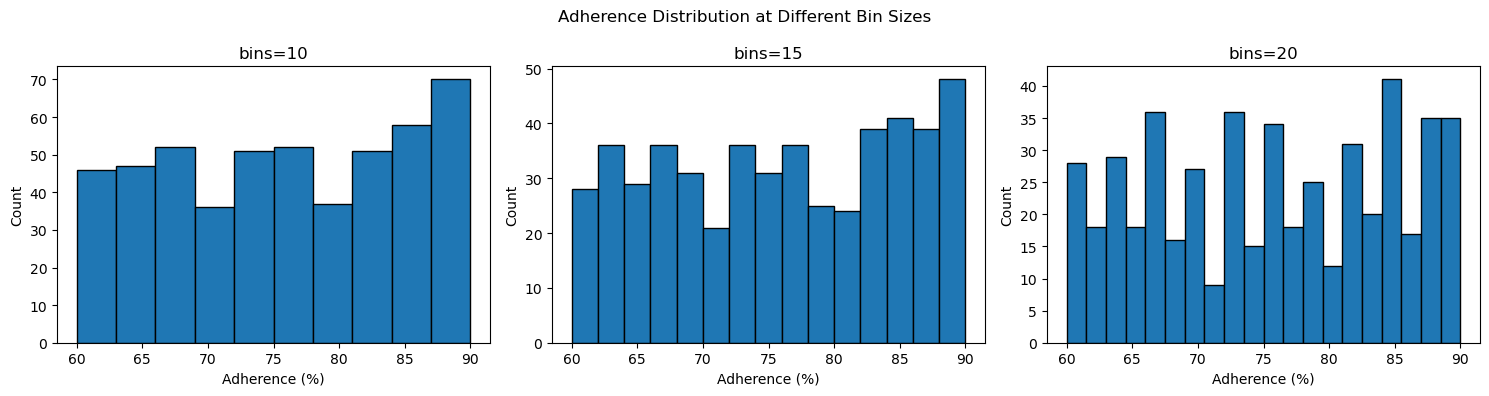

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
bin_options = [10, 15, 20]

for ax, bins in zip(axes, bin_options):
    ax.hist(df['Adherence to Treatment (%)'], bins=bins, edgecolor='black')
    ax.set_title(f'bins={bins}')
    ax.set_xlabel('Adherence (%)')
    ax.set_ylabel('Count')

plt.suptitle('Adherence Distribution at Different Bin Sizes')
plt.tight_layout()
plt.show()

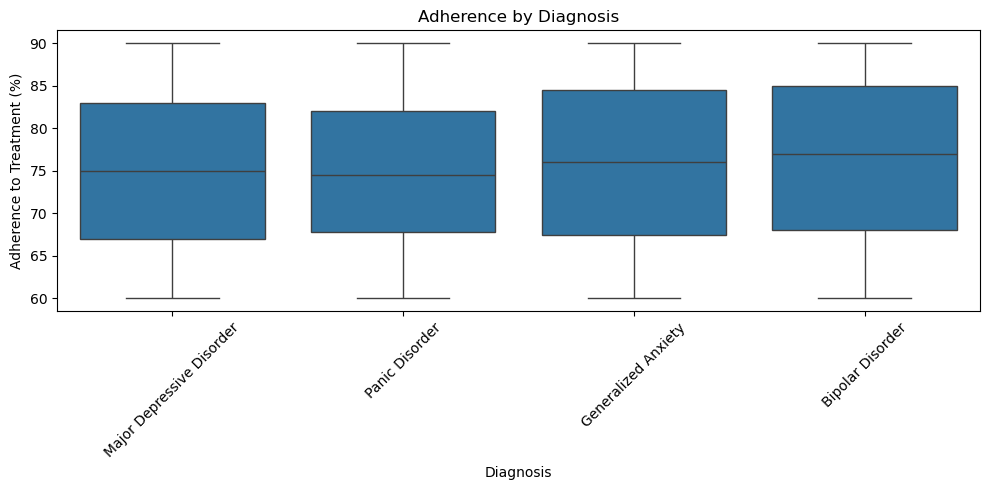

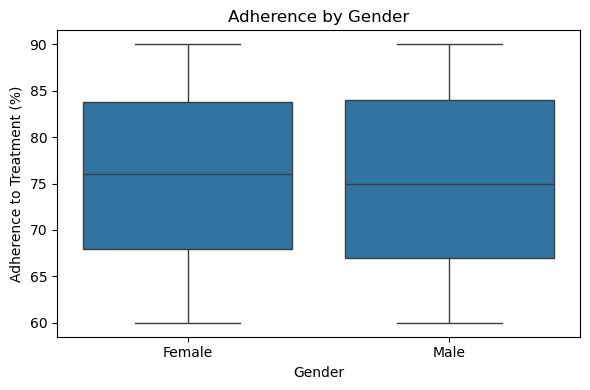

In [7]:
# adherence by diagnosis
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='Diagnosis', y='Adherence to Treatment (%)')
plt.xticks(rotation=45)
plt.title('Adherence by Diagnosis')
plt.tight_layout()
plt.show()

# adherence by gender
plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x='Gender', y='Adherence to Treatment (%)')
plt.title('Adherence by Gender')
plt.tight_layout()
plt.show()

In [8]:
# possible adherence threshold choices
# Option A: equal width splits
# Option B: Quantile/percent based splits
    # gives room for more equal number of participants in each class which can be important due to dataset size
t1 = df['Adherence to Treatment (%)'].quantile(0.33)
t2 = df['Adherence to Treatment (%)'].quantile(0.67)

print(f"33rd percentile (Low/Medium boundary): {t1:.1f}")
print(f"67th percentile (Medium/High boundary): {t2:.1f}")

def label_adherence(pct):
    if pct <= t1:
        return 0
    elif pct <= t2:
        return 1
    else:
        return 2

df['Adherence_Class'] = df['Adherence to Treatment (%)'].apply(label_adherence)
print(df['Adherence_Class'].value_counts().sort_index())

33rd percentile (Low/Medium boundary): 70.0
67th percentile (Medium/High boundary): 82.0
Adherence_Class
0    172
1    180
2    148
Name: count, dtype: int64


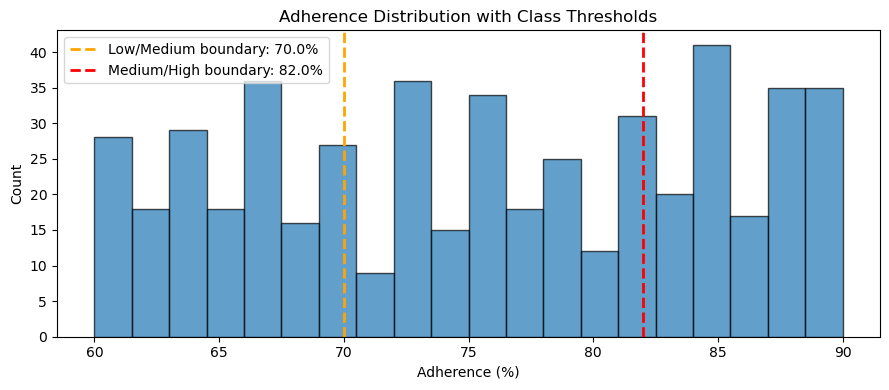

In [9]:
plt.figure(figsize=(9, 4))
plt.hist(df['Adherence to Treatment (%)'], bins=20, edgecolor='black', alpha=0.7)
plt.axvline(t1, color='orange', linewidth=2, linestyle='--', label=f'Low/Medium boundary: {t1:.1f}%')
plt.axvline(t2, color='red', linewidth=2, linestyle='--', label=f'Medium/High boundary: {t2:.1f}%')
plt.title('Adherence Distribution with Class Thresholds')
plt.xlabel('Adherence (%)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# pre-treatment features
features_to_keep = [
    'Patient ID', 'Age', 'Gender', 'Diagnosis', 'Symptom Severity (1-10)',
    'Medication', 'Therapy Type', 'Stress Level (1-10)',
    'Sleep Quality (1-10)', 'Physical Activity (hrs/week)', 'Treatment Start Date'
]

print(df[features_to_keep].dtypes)

Patient ID                       int64
Age                              int64
Gender                          object
Diagnosis                       object
Symptom Severity (1-10)          int64
Medication                      object
Therapy Type                    object
Stress Level (1-10)              int64
Sleep Quality (1-10)             int64
Physical Activity (hrs/week)     int64
Treatment Start Date            object
dtype: object


In [11]:
#Feature Encoding and scaling values, done on a copy of the dataset awaiting any modifications 
from sklearn.preprocessing import TargetEncoder
#Drop unnecessary features
features_to_drop = [
    'Treatment Duration (weeks)',
    'Outcome',
    'Treatment Progress (1-10)',
    'AI-Detected Emotional State',
    'Adherence to Treatment (%)',
    'Patient ID',
    'Mood Score (1-10)'
]
df2= df.copy()
# df2.drop(columns= features_to_drop, inplace=True )
# # checking unique values in non-numerical columns to decipher encoding methods
# print(df2['Medication'].unique())
# print(df2['Diagnosis'].unique())
# print(df2['Therapy Type'].unique())
# low cardinality features, which call for one-hot encoding
# We want to know how much each of these features contributes to adherence

In [12]:
# Encode non-numerical features 
# Convert 'Treatment Start Date' to flat integer 'Treatment Days' which aims to 
# capture the significance of treatment dates to predicting adherence
# Simple conversion allows comparability to other numeric features
df2['Treatment Start Date'] = pd.to_datetime(df2['Treatment Start Date'])
df2['Treatment Days'] = (df2['Treatment Start Date'] - df2['Treatment Start Date'].min()).dt.days
df2.drop('Treatment Start Date', axis=1, inplace=True)

# Use one-hot encoding for nominal variables without ordinal significance
df2 = pd.get_dummies(df2, columns=['Gender', 'Therapy Type', 'Diagnosis', 'Medication', 'Outcome', 'AI-Detected Emotional State'], drop_first=True)
df2 = df2.astype({col: int for col in df2.select_dtypes('bool').columns})

display(df2.head())

# Next Steps: Scaling and splitting the data for model training
# Plan to standardize feature values
# Plan to partition data into training and testing sets
# Plan to apply percentage based thresholding

,Patient ID,Age,Symptom Severity (1-10),Mood Score (1-10),Sleep Quality (1-10),Physical Activity (hrs/week),Treatment Duration (weeks),Stress Level (1-10),Treatment Progress (1-10),Adherence to Treatment (%),...,Medication_Benzodiazepines,Medication_Mood Stabilizers,Medication_SSRIs,Outcome_Improved,Outcome_No Change,AI-Detected Emotional State_Depressed,AI-Detected Emotional State_Excited,AI-Detected Emotional State_Happy,AI-Detected Emotional State_Neutral,AI-Detected Emotional State_Stressed
0,1,43,10,5,8,5,11,9,7,66,...,0,1,0,0,0,0,0,0,0,0
1,2,40,9,5,4,7,11,7,7,78,...,0,0,0,0,1,0,0,0,1,0
2,3,55,6,3,4,3,14,7,5,62,...,0,0,1,0,0,0,0,1,0,0
3,4,34,6,3,6,5,8,8,10,72,...,0,0,1,0,0,0,1,0,0,0
4,5,52,7,6,6,8,12,5,6,63,...,0,0,0,0,0,0,1,0,0,0


In [13]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
# Checking for multicollinearity to identify if there are any highly correlated features
X = df2.drop('Adherence_Class', axis=1)

X['intercept'] = 1

vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]

print(vif_data.sort_values(by="VIF", ascending=False))

                                        feature         VIF
30                                    intercept  253.640795
22                             Medication_SSRIs    1.874640
18                    Medication_Antipsychotics    1.856828
21                  Medication_Mood Stabilizers    1.850359
20                   Medication_Benzodiazepines    1.836218
19                       Medication_Anxiolytics    1.702143
14       Therapy Type_Mindfulness-Based Therapy    1.677336
26          AI-Detected Emotional State_Excited    1.665926
13           Therapy Type_Interpersonal Therapy    1.663029
28          AI-Detected Emotional State_Neutral    1.636763
29         AI-Detected Emotional State_Stressed    1.628833
12  Therapy Type_Dialectical Behavioral Therapy    1.605396
16          Diagnosis_Major Depressive Disorder    1.605330
15                Diagnosis_Generalized Anxiety    1.594769
17                     Diagnosis_Panic Disorder    1.564348
27            AI-Detected Emotional Stat

In [14]:
#checking what features to use for new apporoach
# print(df2.columns.tolist())
corr_matrix = df2.corr()

target = 'Treatment Duration (weeks)'
correlations = corr_matrix[target].sort_values(ascending=False)

print("Features most correlated with Treatment Duration:")
print(correlations)

relevant_features = correlations[abs(correlations) > 0.2].index.tolist()
print("\nSuggested features for your model:", relevant_features)
#The features we have are not suited for predicting treatment duration or adherence effectively.

Features most correlated with Treatment Duration:
Treatment Duration (weeks)                     1.000000
Medication_Anxiolytics                         0.049793
Outcome_No Change                              0.044929
AI-Detected Emotional State_Stressed           0.043423
Medication_Mood Stabilizers                    0.039873
Stress Level (1-10)                            0.037554
Diagnosis_Generalized Anxiety                  0.031684
Therapy Type_Dialectical Behavioral Therapy    0.027763
AI-Detected Emotional State_Excited            0.018887
Gender_Male                                    0.012723
Symptom Severity (1-10)                        0.008522
AI-Detected Emotional State_Happy              0.007731
Sleep Quality (1-10)                           0.007402
Outcome_Improved                               0.005714
AI-Detected Emotional State_Depressed          0.000975
Treatment Progress (1-10)                     -0.001418
Medication_Antipsychotics                     -0.00339

In [15]:
# ============================================================
# redo df2 for sake of model testing and comparison 
# ============================================================

df2 = df.copy()

# drop all posttreatment features
features_to_drop = [
    'Treatment Duration (weeks)',
    'Outcome',
    'Treatment Progress (1-10)',
    'AI-Detected Emotional State',
    'Adherence to Treatment (%)',
    'Patient ID',
    'Mood Score (1-10)'
]
df2.drop(columns=features_to_drop, inplace=True)

# convert treatment start date to numeric
df2['Treatment Start Date'] = pd.to_datetime(df2['Treatment Start Date'])
df2['Treatment Days'] = (df2['Treatment Start Date'] - df2['Treatment Start Date'].min()).dt.days
df2.drop('Treatment Start Date', axis=1, inplace=True)

# one hot encode only pre-treatment categorical columns
df2 = pd.get_dummies(df2, columns=['Gender', 'Therapy Type', 'Diagnosis', 'Medication'], drop_first=True)
df2 = df2.astype({col: int for col in df2.select_dtypes('bool').columns})

# confirm columns are correct
print("Columns:", df2.columns.tolist())
print("Shape:", df2.shape)

Columns: ['Age', 'Symptom Severity (1-10)', 'Sleep Quality (1-10)', 'Physical Activity (hrs/week)', 'Stress Level (1-10)', 'Adherence_Class', 'Treatment Days', 'Gender_Male', 'Therapy Type_Dialectical Behavioral Therapy', 'Therapy Type_Interpersonal Therapy', 'Therapy Type_Mindfulness-Based Therapy', 'Diagnosis_Generalized Anxiety', 'Diagnosis_Major Depressive Disorder', 'Diagnosis_Panic Disorder', 'Medication_Antipsychotics', 'Medication_Anxiolytics', 'Medication_Benzodiazepines', 'Medication_Mood Stabilizers', 'Medication_SSRIs']
Shape: (500, 19)


In [16]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# all features saved to X, target labels saved to y
X = df2.drop('Adherence_Class', axis=1)
y = df2['Adherence_Class']

# 85/15 split, stratified to preserve class balance across splits
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# fit scaler on training data only to avoid data leakage
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns
)

base logistic regression cv results
CV F1 scores per fold: [0.278 0.27  0.34  0.305 0.298 0.334 0.284 0.355 0.435 0.478]
Mean F1: 0.338
Std Dev: 0.066
Test Set Classification Report:
              precision    recall  f1-score   support

         Low       0.23      0.35      0.28        26
      Medium       0.33      0.26      0.29        27
        High       0.27      0.18      0.22        22

    accuracy                           0.27        75
   macro avg       0.28      0.26      0.26        75
weighted avg       0.28      0.27      0.26        75



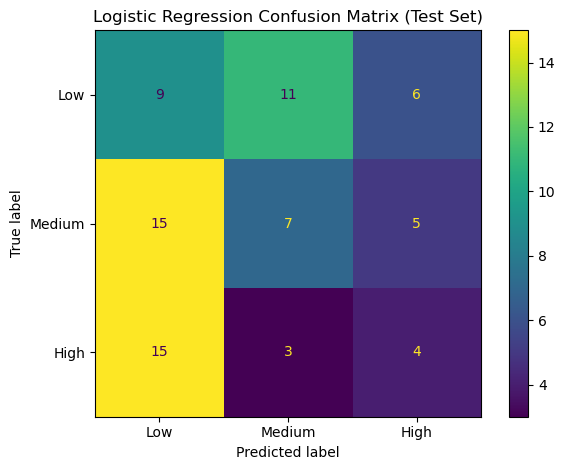

In [17]:
# ============================================================
# logistic regression model for classification (original idea) 
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# train baseline logistic regression model
lr_model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
lr_model.fit(X_train_scaled, y_train)

# stratified 10-fold cross validation on training set
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    lr_model, X_train_scaled, y_train,
    cv=skf, scoring='f1_macro'
)

# mean used to see model performance over multiple folds
# std dev used for model consistency
print("base logistic regression cv results")
print(f"CV F1 scores per fold: {cv_scores.round(3)}")
print(f"Mean F1: {cv_scores.mean():.3f}")
print(f"Std Dev: {cv_scores.std():.3f}")

print("="*60)

# evaluate on held out test set
y_pred_lr = lr_model.predict(X_test_scaled)
print("Test Set Classification Report:")
print(classification_report(y_test, y_pred_lr, target_names=['Low', 'Medium', 'High']))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Low', 'Medium', 'High'])
disp.plot()
plt.title('Logistic Regression Confusion Matrix (Test Set)')
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# doing problem as regression to see if its better suited for
# the problem than classificaition 
# ============================================================
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# use raw continuous adherence percentage as target for regression comparison
y_raw = df['Adherence to Treatment (%)']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y_raw, test_size=0.15, random_state=42
)

# fit scaler on training data only
X_train_r_scaled = pd.DataFrame(scaler.fit_transform(X_train_r), columns=X.columns)
X_test_r_scaled = pd.DataFrame(scaler.transform(X_test_r), columns=X.columns)

# train linear regression model
reg_model = LinearRegression()
reg_model.fit(X_train_r_scaled, y_train_r)

# evaluate on test set
y_pred_r = reg_model.predict(X_test_r_scaled)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))
r2 = r2_score(y_test_r, y_pred_r)

# how off the models prediction is on avgerage
# proportion of variance
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")

RMSE: 9.449
R²: -0.032


In [19]:
# ============================================================
# test alternative classifier models
# ============================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# define all five models to compare with default hyperparameters
models = {
    'Logistic Regression': LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42)
}

# save the 10 fold score per model
results = {}
for name, model in models.items():
    # runs the full train/evaluate cycle once per fold and save scores
    scores = cross_val_score(
        model, X_train_scaled, y_train,
        cv=skf, scoring='f1_macro'
    )
    results[name] = scores
    print(f"{name}:")
    print(f"  Mean F1: {scores.mean():.3f}")
    print(f"  Std Dev: {scores.std():.3f}")

Logistic Regression:
  Mean F1: 0.338
  Std Dev: 0.066
Decision Tree:
  Mean F1: 0.324
  Std Dev: 0.046
Random Forest:
  Mean F1: 0.274
  Std Dev: 0.076
KNN:
  Mean F1: 0.317
  Std Dev: 0.073
SVM:
  Mean F1: 0.320
  Std Dev: 0.067


In [20]:
# ============================================================
# test set evaluation for previous models
# ============================================================
from sklearn.metrics import f1_score

# untuned model test set evaluation 
untuned_test_results = {}

# for each model do test set evaluation
for name, model in models.items():
    # refit the model on the full training set before predicting
    # since in cross validation each model was only fit on subsets of training data
    model.fit(X_train_scaled, y_train)

    # generate predictions
    y_pred = model.predict(X_test_scaled)

    # get macro f1 score for performance evlauation
    f1 = f1_score(y_test, y_pred, average='macro')
    untuned_test_results[name] = f1

# turn reslts into nice df
untuned_test_results_df = pd.DataFrame.from_dict(
    untuned_test_results, orient='index', columns=['Untuned Test F1']
).sort_values('Untuned Test F1', ascending=False)

# print df
print(untuned_test_results_df.round(3))

                     Untuned Test F1
Decision Tree                  0.398
Logistic Regression            0.262
Random Forest                  0.234
SVM                            0.232
KNN                            0.209


In [21]:
# ============================================================
# hyper parameter tuning w random search on classification models from slight hunch classification better
# ============================================================

from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# define the hyperparameter search space for each model
# each key is a hyperparameter name and each value is either a distribution or a list of options to choose from
param_distributions = {
    # C: regularization strength
    # penatly: type of regularization applied
    # liblinear solver is used because it supports both l1 and l2 penalties
    'Logistic Regression': {
        'C': uniform(0.01, 100),
        'penalty': ['l1', 'l2'],
        'solver': ['liblinear']
    },
    # max_depth: how deep the tree can grow 
    # min_samples_split: min num of samples needed to split a node
    # min_samples_leaf: min num of samples required at a leaf node
    # criterion: how the tree measures split quality
        # gini: impurity, entropy: information gain
    'Decision Tree': {
        'max_depth': [3, 5, 10, None],
        'min_samples_split': randint(2, 20),
        'min_samples_leaf': randint(1, 10),
        'criterion': ['gini', 'entropy']
    },
    # n_estimators: number of trees in the forest
    # max_depth: limits tree depth in the forest
    # min_samples_split: min samples needed to split
    # max_features: how many features each tree considers at each split
        # sqrt: square root of total features, log2: log base 2
    'Random Forest': {
        'n_estimators': randint(50, 300),
        'max_depth': [3, 5, 10, None],
        'min_samples_split': randint(2, 20),
        'max_features': ['sqrt', 'log2']
    },
    # n_neighbors: nearest neighbors to consider when making a prediction
    # weights: how neighbors contribute to the prediction
    # metric: how distance between points is calculated
    'KNN': {
        'n_neighbors': randint(3, 20),
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    },
    # C: regularization parameter 
    # kernel: how the SVM maps data into higher dimensional space
    # gamma: the influence radius of each training point
    'SVM': {
        'C': uniform(0.1, 100),
        'kernel': ['linear', 'rbf', 'poly'],
        'gamma': ['scale', 'auto']
    }
}

# new model instances for fine tuning purpose
base_models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'KNN': KNeighborsClassifier(),
    'SVM': SVC(random_state=42)
}

best_models = {}
tuning_results = {}

for name in base_models:
    print(f"{name}")

    # configure RandomizedSearchCV for this model
    random_search = RandomizedSearchCV(
        base_models[name],
        param_distributions[name],
        n_iter=50, # 50 iterations per 10 folds = 500 fits per model
        cv=skf,
        scoring='f1_macro',
        random_state=42
    )
    # fit runs all 500 combinations and selects the best performing parameter set
    random_search.fit(X_train_scaled, y_train)
    # the model already fitted with the best found parameters
    best_models[name] = random_search.best_estimator_
    # store  parameters and best CV F1 for reporting and comparison
    tuning_results[name] = {
        'best_params': random_search.best_params_,
        'best_cv_f1': random_search.best_score_
    }
    print(f"Best Params: {random_search.best_params_}")
    print(f"Best CV F1:  {random_search.best_score_:.3f}")
    print("=" * 60)

Logistic Regression
Best Params: {'C': np.float64(0.08787658410143283), 'penalty': 'l2', 'solver': 'liblinear'}
Best CV F1:  0.347
Decision Tree
Best Params: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 6}
Best CV F1:  0.366
Random Forest
Best Params: {'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 8, 'n_estimators': 290}
Best CV F1:  0.304
KNN
Best Params: {'metric': 'euclidean', 'n_neighbors': 4, 'weights': 'distance'}
Best CV F1:  0.361
SVM
Best Params: {'C': np.float64(4.766566321361543), 'gamma': 'auto', 'kernel': 'poly'}
Best CV F1:  0.333


In [22]:
# ============================================================
# test set evaulation on tuned models
# ============================================================
from sklearn.metrics import f1_score

test_results = {}

# test set evlauation for each tuned model
for name, model in best_models.items():
    # generate test set predictions
    y_pred = model.predict(X_test_scaled)
    # get f1 score for evaluation 
    f1 = f1_score(y_test, y_pred, average='macro')
    test_results[name] = f1

# display results in df format
test_results_df = pd.DataFrame.from_dict(
    test_results, orient='index', columns=['Tuned Test F1']
).sort_values('Tuned Test F1', ascending=False)
print(test_results_df.round(3))

                     Tuned Test F1
KNN                          0.284
SVM                          0.278
Random Forest                0.269
Decision Tree                0.245
Logistic Regression          0.234


In [23]:
# full comparison table: untuned CV, untuned test, tuned CV, tuned test
summary = pd.DataFrame({
    'Untuned CV F1': {name: results[name].mean() for name in results},
    'Untuned Test F1': untuned_test_results,
    'Tuned CV F1': {name: tuning_results[name]['best_cv_f1'] for name in tuning_results},
    'Tuned Test F1': test_results
}).sort_values('Tuned CV F1', ascending=False)

print(summary.round(3))

                     Untuned CV F1  Untuned Test F1  Tuned CV F1  \
Decision Tree                0.324            0.398        0.366   
KNN                          0.317            0.209        0.361   
Logistic Regression          0.338            0.262        0.347   
SVM                          0.320            0.232        0.333   
Random Forest                0.274            0.234        0.304   

                     Tuned Test F1  
Decision Tree                0.245  
KNN                          0.284  
Logistic Regression          0.234  
SVM                          0.278  
Random Forest                0.269  


Adherence_Class
1    180
0    172
2    148
Name: count, dtype: int64


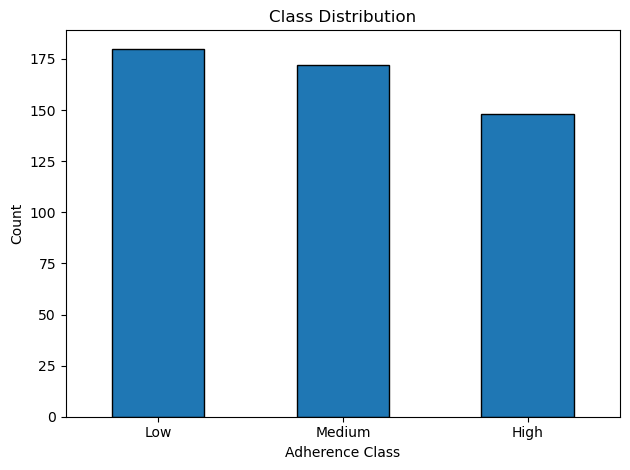

In [24]:
# check for target class imbalance of target variable
print(df2['Adherence_Class'].value_counts())
df2['Adherence_Class'].value_counts().plot(kind='bar', edgecolor='black')
plt.title('Class Distribution')
plt.xlabel('Adherence Class')
plt.ylabel('Count')
plt.xticks([0,1,2], ['Low', 'Medium', 'High'], rotation=0)
plt.tight_layout()
plt.show()

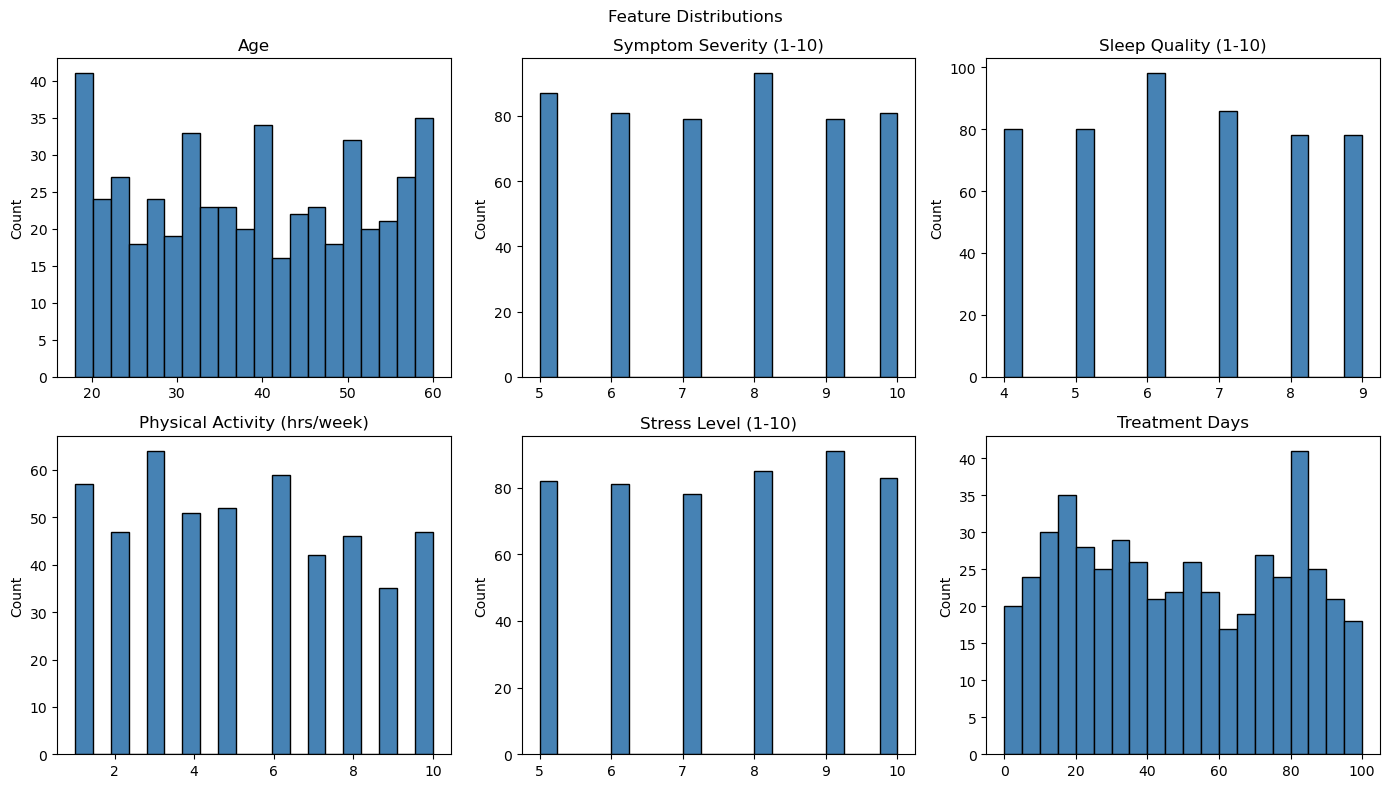

In [25]:
# check feature distribution on numeric features 

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
numeric_features = ['Age', 'Symptom Severity (1-10)', 'Sleep Quality (1-10)',
                    'Physical Activity (hrs/week)', 'Stress Level (1-10)', 'Treatment Days']

for ax, col in zip(axes.flatten(), numeric_features):
    ax.hist(df2[col], bins=20, color='steelblue', edgecolor='black')
    ax.set_title(col)
    ax.set_ylabel('Count')

plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

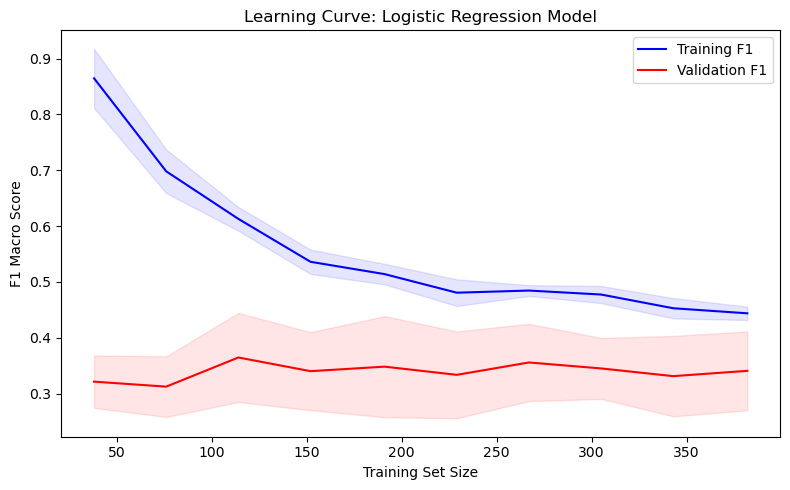

In [33]:
# learning curve analysis: rule out if data size is the issue

from sklearn.model_selection import learning_curve

# train_sizes: num of training samples used at each step
# train_scores: f1 scores on the train set at each size
# val_scores: f1 scores on the val set at each size
train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42),
    X_train_scaled, y_train,
    cv=skf, scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

plt.figure(figsize=(8, 5))
# plot mean training f1 across all folds for how well the model fits training data
plt.plot(train_sizes, train_scores.mean(axis=1), label='Training F1', color='blue')
# plot mean validation across all folds
plt.plot(train_sizes, val_scores.mean(axis=1), label='Validation F1', color='red')

# shaded region is one std dev above and below the mean
# a wide band -> performance varies considerably across folds at that training size
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color='blue')
# repeat for validation curve
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1, color='red')
plt.title('Learning Curve: Logistic Regression Model')
plt.xlabel('Training Set Size')
plt.ylabel('F1 Macro Score')
plt.legend()
plt.tight_layout()
plt.show()

# training f1 decreasing as size grows -> when model trains on a small subset of data it can memorize those few samples and get a high F1
# but as you add more training data it can no longer memorize everything and performance drops toward the true underlying signal level
# implies underfitting and that the model never actually learns a meaningful pattern but it just memorizes on small subsets

# validation f1 flat the whole -> adding more training data doesn't give benefit to generalization
# expect validation performance to improve as training size grows because more data helps the model learn better patterns
# staying flat confirms there are no learnable patterns in the features to begin with

# rules out that dataset size is the cause of failure

Diagnosis_Panic Disorder                      -0.050030
Treatment Days                                -0.046351
Symptom Severity (1-10)                       -0.046324
Physical Activity (hrs/week)                  -0.045913
Medication_Antipsychotics                     -0.045081
Stress Level (1-10)                           -0.030787
Diagnosis_Major Depressive Disorder           -0.023136
Gender_Male                                   -0.021242
Age                                           -0.017948
Therapy Type_Mindfulness-Based Therapy        -0.015759
Medication_Mood Stabilizers                    0.001163
Medication_SSRIs                               0.008328
Medication_Benzodiazepines                     0.008605
Sleep Quality (1-10)                           0.009510
Therapy Type_Interpersonal Therapy             0.017120
Medication_Anxiolytics                         0.017278
Diagnosis_Generalized Anxiety                  0.030914
Therapy Type_Dialectical Behavioral Therapy    0

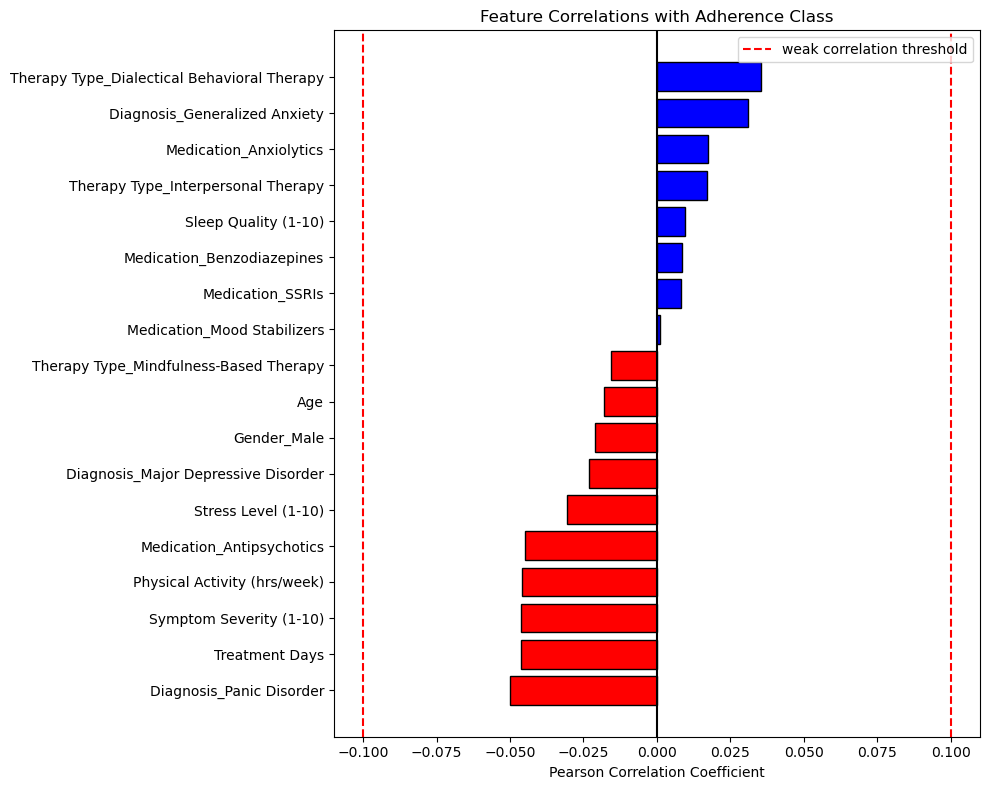

Max absolute correlation: 0.0500
Mean absolute correlation: 0.0262
All features below 0.1 threshold? True


In [43]:
# feature correlations with adherence class (pearsons)

# compute pearson correlation between every feature in df2 and Adherence_Class
correlations = df2.corr()['Adherence_Class'].drop('Adherence_Class').sort_values()
print(correlations)

plt.figure(figsize=(10, 8))

# assign colors based on direction of correlation
colors = ['red' if x < 0 else 'blue' for x in correlations]
# make horizontal bar plot
plt.barh(correlations.index, correlations.values, color=colors, edgecolor='black')
# set line that represents 0 points for reference
plt.axvline(x=0, color='black')
# set lines to see where correlation threshold falls
plt.axvline(x=0.1, color='red', linestyle='--', label='weak correlation threshold')
plt.axvline(x=-0.1, color='red', linestyle='--')


plt.title('Feature Correlations with Adherence Class')
plt.xlabel('Pearson Correlation Coefficient')
plt.legend()
plt.tight_layout()
plt.show()

# largest correlation
print(f"Max absolute correlation: {correlations.abs().max():.4f}")
# avg correlation
print(f"Mean absolute correlation: {correlations.abs().mean():.4f}")
# check if all features fall under weak threshold
print("All features below 0.1 threshold?", (correlations.abs() < 0.1).all())

Top 3 features: Mean F1 = 0.308 (Std: 0.071)
Top 5 features: Mean F1 = 0.332 (Std: 0.048)
Top 8 features: Mean F1 = 0.355 (Std: 0.079)
Top 10 features: Mean F1 = 0.354 (Std: 0.084)
Top 18 features: Mean F1 = 0.338 (Std: 0.066)


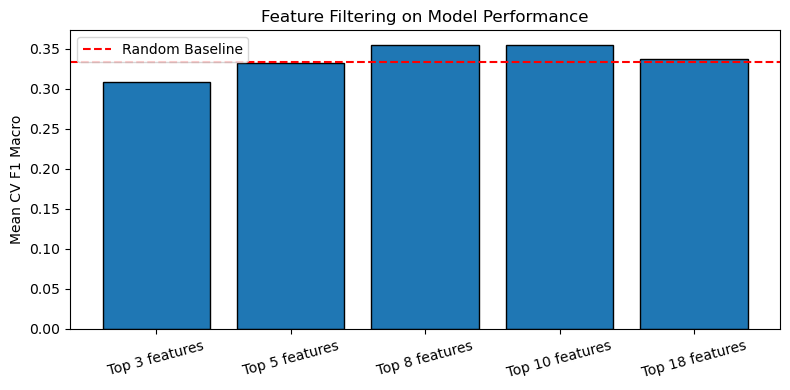

In [41]:
# feature filtering analysis: test if removing weak features improves model performance

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score

# try keeping only top N features by absolute correlation
filtering_results = {}

# iterate over different feature subset sizes to test how many features gives the best performance
for n_features in [3, 5, 8, 10, len(df2.columns)-1]:
    # select top n features by absolute correlation with target
    top_features = correlations.abs().sort_values(ascending=False).head(n_features).index.tolist()

    # subset the training and test sets to only include the selected features
    X_filtered = X_train_scaled[top_features]
    X_test_filtered = X_test_scaled[top_features]

    # use a new logistic regression model for each subset size
    model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)

    # evaluate model on the filtered feature set using cv
    scores = cross_val_score(model, X_filtered, y_train, cv=skf, scoring='f1_macro')
    # store results for analysis
    filtering_results[f'Top {n_features} features'] = scores.mean()
    print(f"Top {n_features} features: Mean F1 = {scores.mean():.3f} (Std: {scores.std():.3f})")

# visualize filtering results
plt.figure(figsize=(8, 4))
plt.bar(filtering_results.keys(), filtering_results.values(), edgecolor='black')
# establish random baseline performance for comparison
plt.axhline(y=0.333, color='red', linestyle='--', label='Random Baseline')
plt.title('Feature Filtering on Model Performance')
plt.ylabel('Mean CV F1 Macro')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

# performance peaks at Top 8 features and then slightly drops as you add more features
# the best possible performance with any subset of features is 0.355, basically at random chance (0.333)
# this means no combination of features, however carefully selected, can push the model to meaningful performance
# the ceiling is random chance despite filtering
# adding more features beyond slightly hurts performance and shows noise accumulation
# the weakest features aren't adding signal, just confusion
# but even removing them only gets you to 0.355 which is still near random.
# even reducing to only 3 features hurts performance and shows that even the "best" features individually carry almost nothing useful

Original: 0.338
Log Transform: 0.350
Square Root Transform: 0.341
Polynomial Features: 0.333


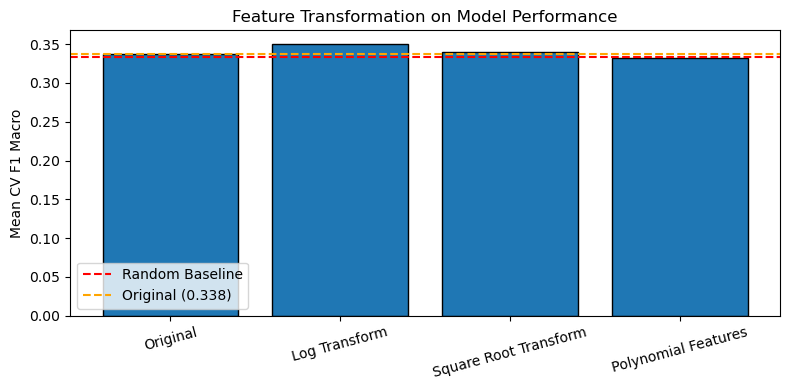

In [42]:
# feature transformation analysis: test if transforming features can reveal a hidden signal that original features dont
import numpy as np
from scipy import stats
from sklearn.preprocessing import PolynomialFeatures

# get numeric features
numeric_features = ['Age', 'Symptom Severity (1-10)', 'Sleep Quality (1-10)',
                    'Physical Activity (hrs/week)', 'Stress Level (1-10)']

transformation_results = {}

# establish baseline score w/ baseline model
model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
# get baseline score w/ no feature transformation
baseline_score = cross_val_score(model, X_train_scaled, y_train, cv=skf, scoring='f1_macro').mean()
transformation_results['Original'] = baseline_score
print(f"Original: {baseline_score:.3f}")

# log transformation: helps with right-skewed distributions
# make copies of train and test to prevent cross overs
X_log = X_train_scaled.copy()
X_test_log = X_test_scaled.copy()
for col in numeric_features:
    # shift to ensure all values positive before log
    shift = abs(X_log[col].min()) + 1
    # apply shift to train and test set to prevent undefined values
    X_log[col] = np.log(X_log[col] + shift)
    X_test_log[col] = np.log(X_test_log[col] + shift)

# evaluate logistic regression on log-transformed features
scores = cross_val_score(model, X_log, y_train, cv=skf, scoring='f1_macro')
transformation_results['Log Transform'] = scores.mean()
print(f"Log Transform: {scores.mean():.3f}")

# square root transformation: moderate skew correction
X_sqrt = X_train_scaled.copy()
for col in numeric_features:
    # same shifting logic
    shift = abs(X_sqrt[col].min()) + 1
    X_sqrt[col] = np.sqrt(X_sqrt[col] + shift)

# evaluate logistic regression on square root transformed features
scores = cross_val_score(model, X_sqrt, y_train, cv=skf, scoring='f1_macro')
transformation_results['Square Root Transform'] = scores.mean()
print(f"Square Root Transform: {scores.mean():.3f}")

# polynomial features: captures non-linear relationships
poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
# fit polynomial transformer on training data only 
X_poly = poly.fit_transform(X_train_scaled)
# apply transformation onto test set
X_test_poly = poly.transform(X_test_scaled)

# evaluate logistic regression on polynomial expanded features
scores = cross_val_score(model, X_poly, y_train, cv=skf, scoring='f1_macro')
transformation_results['Polynomial Features'] = scores.mean()
print(f"Polynomial Features: {scores.mean():.3f}")

# visualize transformation results
plt.figure(figsize=(8, 4))
# one bar per transformation
plt.bar(transformation_results.keys(), transformation_results.values(), edgecolor='black')
# establish random baseline performance for comparison
plt.axhline(y=0.333, color='red', linestyle='--', label='Random Baseline')
# establish original model performance for comparison
plt.axhline(y=baseline_score, color='orange', linestyle='--', label=f'Original ({baseline_score:.3f})')
plt.title('Feature Transformation on Model Performance')
plt.ylabel('Mean CV F1 Macro')
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

# log transformation (0.350) shows the largest gain but it's only 0.012 above the original
# Given your std dev of ~0.07 across folds, a difference of 0.012 is completely within random variation and cannot be considered a real improvement.

# Square root transformation (0.341) is essentially identical to the original at 0.338. a difference of 0.003 which is meaningless.

# Polynomial features (0.333) actually dropped back exactly to random chance despite adding interaction terms between all features
# This is particularly telling because polynomial features are specifically designed to capture non-linear relationships
# the fact that they provide zero benefit means there are no non-linear relationships to capture either

# Distributional skewness is not the cause — log and square root transformations are specifically designed to fix skewed distributions
# Neither helped meaningfully, so skewness in the raw features is not what's limiting the model
# Non-linearity is not the cause — polynomial features explicitly model non-linear and interaction effects between features
# The fact that performance dropped to exactly random chance (0.333) when using polynomial features is strong evidence
# that no non-linear signal exists in the data either. 
# This is important because it closes the door on the argument that a more complex non-linear model
# like Random Forest might eventually work with the right transformations.

                                        feature  mutual_information
8            Therapy Type_Interpersonal Therapy              0.0482
7   Therapy Type_Dialectical Behavioral Therapy              0.0369
1                       Symptom Severity (1-10)              0.0354
9        Therapy Type_Mindfulness-Based Therapy              0.0220
11          Diagnosis_Major Depressive Disorder              0.0207
15                   Medication_Benzodiazepines              0.0165
4                           Stress Level (1-10)              0.0160
10                Diagnosis_Generalized Anxiety              0.0121
0                                           Age              0.0062
6                                   Gender_Male              0.0000
5                                Treatment Days              0.0000
3                  Physical Activity (hrs/week)              0.0000
12                     Diagnosis_Panic Disorder              0.0000
13                    Medication_Antipsychotics 

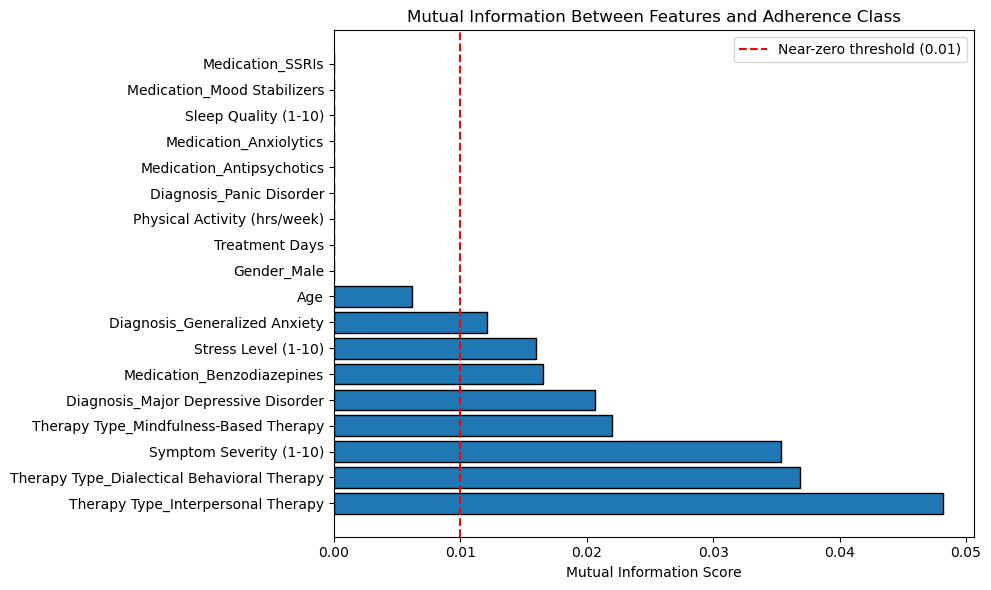

Features with MI > 0.01: 8
Features with MI < 0: 10


In [45]:
# MI feature analysis
# unlike Pearson correlation mutual information captures non-linear relationships too.
# if mi is near zero for all features it means there is no relationship (including non linear) between features and adherence

from sklearn.feature_selection import mutual_info_classif

# compute mutual information between every feature and the adherence class label
mi_scores = mutual_info_classif(X_train_scaled, y_train, random_state=42)
# put into df and display
mi_df = pd.DataFrame({'feature': X.columns, 'mutual_information': mi_scores}).sort_values('mutual_information', ascending=False)
print(mi_df.round(4))

plt.figure(figsize=(10, 6))
# horizontal bar chart for each feature and its mi score w/ adherance 
plt.barh(mi_df['feature'], mi_df['mutual_information'], edgecolor='black')
# mark the 'near-zero' area to see which 
plt.axvline(x=0.01, color='red', linestyle='--', label='Near-zero threshold (0.01)')
plt.title('Mutual Information Between Features and Adherence Class')
plt.xlabel('Mutual Information Score')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Features with MI > 0.01: {(mi_df['mutual_information'] > 0.01).sum()}")
print(f"Features with MI < 0: {(mi_df['mutual_information'] < 0.01).sum()}")

# The features with the highest mutual information are therapy type and symptom severity. 
# This is at least clinically intuitive: the type of therapy a patient receives and how severe
# their symptoms are might reasonably relate to how well they adhere

In [30]:
data = pd.read_csv("mental_health_diagnosis_treatment_.csv")


data['Treatment Start Date'] = pd.to_datetime(data['Treatment Start Date'])
data['Treatment Days'] = (data['Treatment Start Date'] - data['Treatment Start Date'].min()).dt.days
data.drop('Treatment Start Date', axis=1, inplace=True)

# one hot encode only pre-treatment categorical columns
data = pd.get_dummies(data, columns=['Gender', 'Therapy Type', 'Diagnosis', 'Medication', 'Outcome', 'AI-Detected Emotional State'], drop_first=True)
data = data.astype({col: int for col in data.select_dtypes('bool').columns})

# confirm columns are correct
print("Columns:", data.columns.tolist())
print("Shape:", data.shape)



Columns: ['Patient ID', 'Age', 'Symptom Severity (1-10)', 'Mood Score (1-10)', 'Sleep Quality (1-10)', 'Physical Activity (hrs/week)', 'Treatment Duration (weeks)', 'Stress Level (1-10)', 'Treatment Progress (1-10)', 'Adherence to Treatment (%)', 'Treatment Days', 'Gender_Male', 'Therapy Type_Dialectical Behavioral Therapy', 'Therapy Type_Interpersonal Therapy', 'Therapy Type_Mindfulness-Based Therapy', 'Diagnosis_Generalized Anxiety', 'Diagnosis_Major Depressive Disorder', 'Diagnosis_Panic Disorder', 'Medication_Antipsychotics', 'Medication_Anxiolytics', 'Medication_Benzodiazepines', 'Medication_Mood Stabilizers', 'Medication_SSRIs', 'Outcome_Improved', 'Outcome_No Change', 'AI-Detected Emotional State_Depressed', 'AI-Detected Emotional State_Excited', 'AI-Detected Emotional State_Happy', 'AI-Detected Emotional State_Neutral', 'AI-Detected Emotional State_Stressed']
Shape: (500, 30)


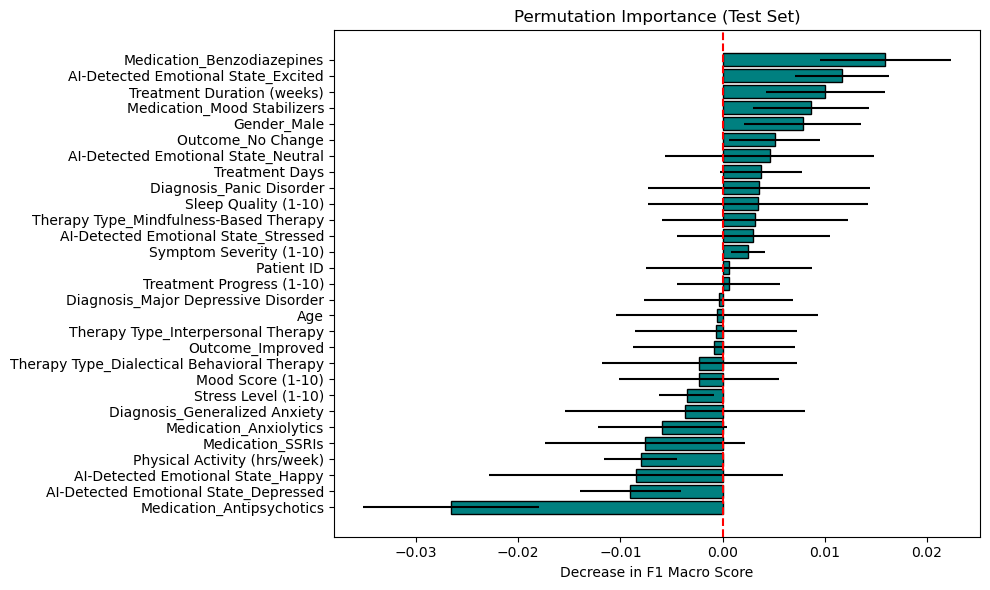

In [48]:
#Permutation Feature Importance (PFI)
#Using our best model from hyperparameter tuning, we can apply permutation feature importance to see which features the model relies on most for its predictions.

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = data.drop('Adherence to Treatment (%)', axis=1)
y = data['Adherence to Treatment (%)']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns
)

from sklearn.neighbors import KNeighborsClassifier
#used KNN based on fine-tuned results 
model_to_test = KNeighborsClassifier(metric='euclidean', n_neighbors=4, weights='distance')

model_to_test.fit(X_train_scaled, y_train)

from sklearn.inspection import permutation_importance

result = permutation_importance(
    model_to_test, X_test_scaled, y_test, 
    n_repeats=10, random_state=42, scoring='f1_macro'
)


# Organize into a DataFrame
perm_importances = pd.Series(result.importances_mean, index=X.columns).sort_values()

# Plot
plt.figure(figsize=(10, 6))
plt.barh(perm_importances.index, perm_importances.values, 
         xerr=result.importances_std, color='teal', edgecolor='black')
plt.axvline(x=0, color='red', linestyle='--')
plt.title('Permutation Importance (Test Set)')
plt.xlabel('Decrease in F1 Macro Score')
plt.tight_layout()
plt.show()

# Reveals high degree of model instability within this feature set
# Several features appear to have negligible impact on model performance
# The features with negative importance suggest that their existence may be detrimental to the model performance
# The standard deviation overlap further signifies the lack of reliability in each feature to predicting adherence. 

/var/folders/gx/s165skpn1yvdvkjjt_btr4b80000gn/T/ipykernel_11483/4020514048.py:40: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot3 = analysis_df.pivot_table(index='Age_Bin', columns='Stress_Bin', values='Is_Error', aggfunc='mean')
/var/folders/gx/s165skpn1yvdvkjjt_btr4b80000gn/T/ipykernel_11483/4020514048.py:47: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot4 = analysis_df.pivot_table(index='Severity_Bin', columns='Sleep_Bin', values='Is_Error', aggfunc='mean')


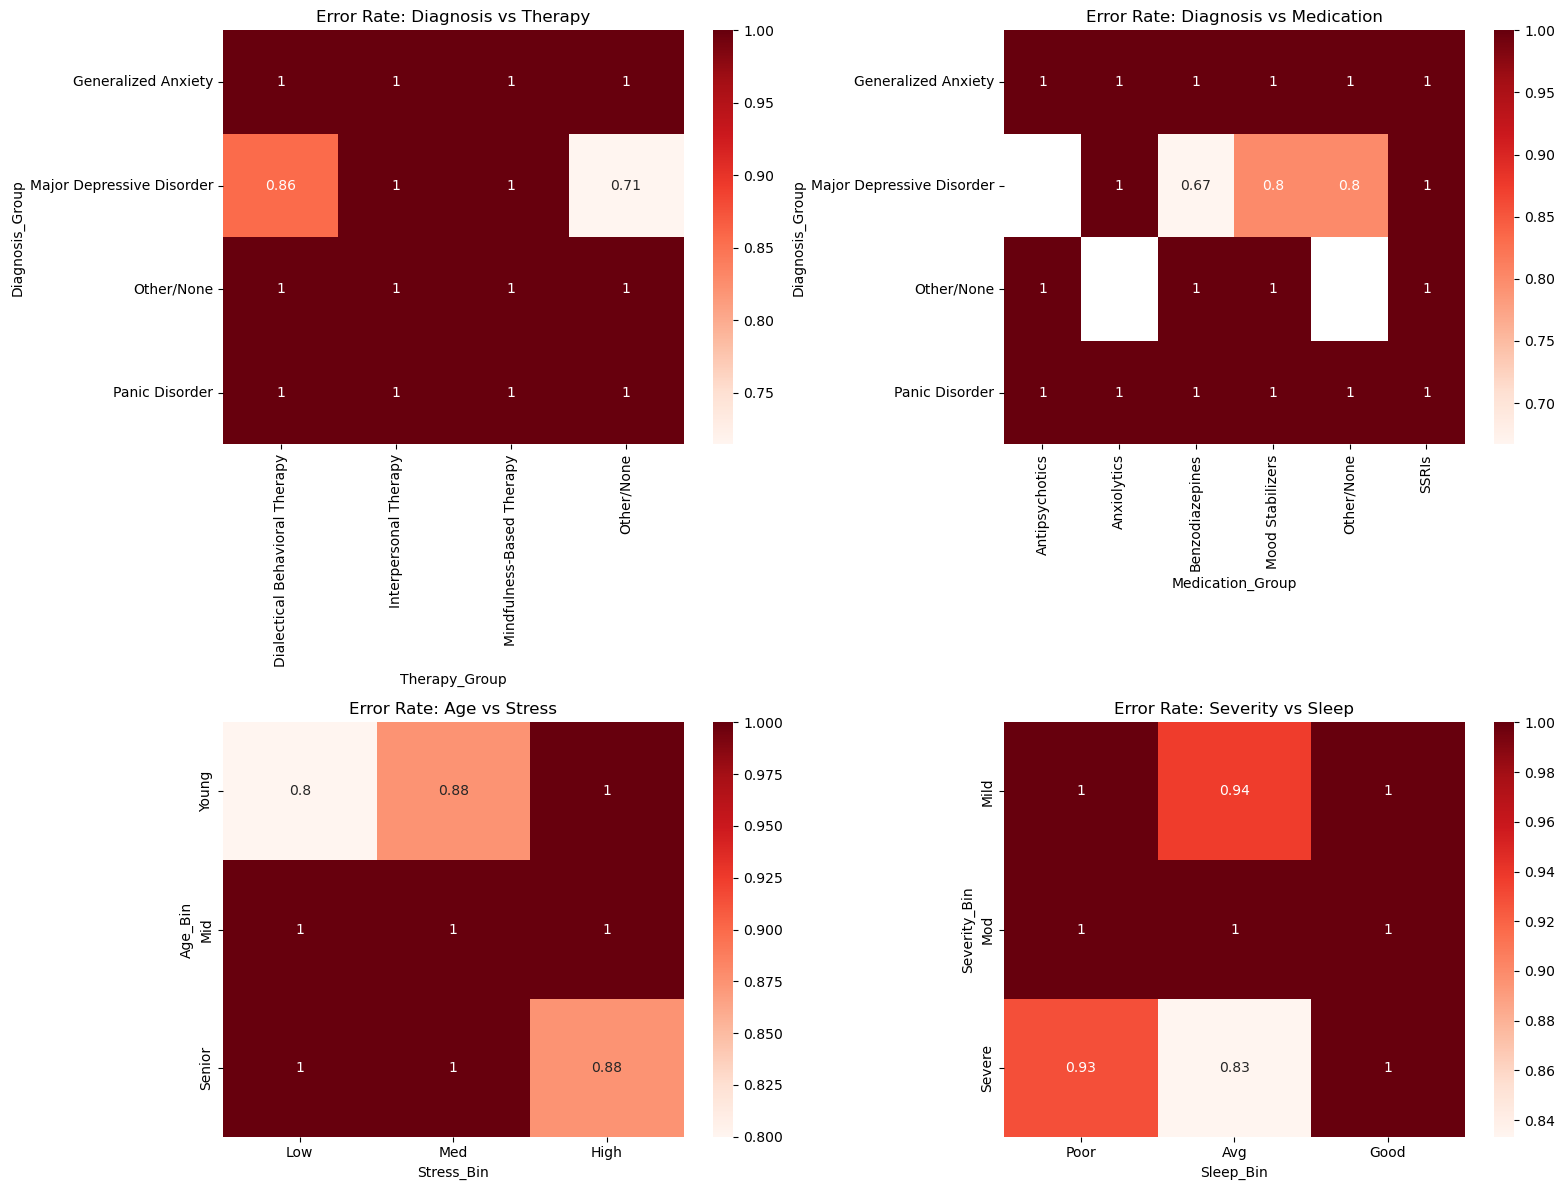

In [49]:
# Misclassification HeatMap
import matplotlib.pyplot as plt
import seaborn as sns

# create a DataFrame to analyze misclassifications
analysis_df = X_test.copy()
analysis_df['Actual'] = y_test.values
analysis_df['Predicted'] = model_to_test.predict(X_test_scaled)
analysis_df['Is_Error'] = (analysis_df['Actual'] != analysis_df['Predicted']).astype(int)

# Identify the categorical columns (finding the one-hot encoded prefixes)
def get_original_cat(row, prefix):
    cols = [c for c in X_test.columns if c.startswith(prefix)]
    for col in cols:
        if row[col] == 1:
            return col.replace(prefix + '_', '')
    return 'Other/None'

analysis_df['Diagnosis_Group'] = analysis_df.apply(lambda r: get_original_cat(r, 'Diagnosis'), axis=1)
analysis_df['Therapy_Group'] = analysis_df.apply(lambda r: get_original_cat(r, 'Therapy Type'), axis=1)
analysis_df['Medication_Group'] = analysis_df.apply(lambda r: get_original_cat(r, 'Medication'), axis=1)

# Set up the subplot grid
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Setting up a couple comparisons 
# 1. Diagnosis vs Therapy
pivot1 = analysis_df.pivot_table(index='Diagnosis_Group', columns='Therapy_Group', values='Is_Error', aggfunc='mean')
sns.heatmap(pivot1, annot=True, cmap='Reds', ax=axes[0, 0])
axes[0, 0].set_title('Error Rate: Diagnosis vs Therapy')

# 2. Diagnosis vs Medication
pivot2 = analysis_df.pivot_table(index='Diagnosis_Group', columns='Medication_Group', values='Is_Error', aggfunc='mean')
sns.heatmap(pivot2, annot=True, cmap='Reds', ax=axes[0, 1])
axes[0, 1].set_title('Error Rate: Diagnosis vs Medication')

# 3. Age (Binned) vs Stress Level (Binned)
analysis_df['Age_Bin'] = pd.cut(analysis_df['Age'], bins=3, labels=['Young', 'Mid', 'Senior'])
analysis_df['Stress_Bin'] = pd.cut(analysis_df['Stress Level (1-10)'], bins=3, labels=['Low', 'Med', 'High'])
pivot3 = analysis_df.pivot_table(index='Age_Bin', columns='Stress_Bin', values='Is_Error', aggfunc='mean')
sns.heatmap(pivot3, annot=True, cmap='Reds', ax=axes[1, 0])
axes[1, 0].set_title('Error Rate: Age vs Stress')

# 4. Symptom Severity vs Sleep Quality
analysis_df['Severity_Bin'] = pd.cut(analysis_df['Symptom Severity (1-10)'], bins=3, labels=['Mild', 'Mod', 'Severe'])
analysis_df['Sleep_Bin'] = pd.cut(analysis_df['Sleep Quality (1-10)'], bins=3, labels=['Poor', 'Avg', 'Good'])
pivot4 = analysis_df.pivot_table(index='Severity_Bin', columns='Sleep_Bin', values='Is_Error', aggfunc='mean')
sns.heatmap(pivot4, annot=True, cmap='Reds', ax=axes[1, 1])
axes[1, 1].set_title('Error Rate: Severity vs Sleep')

plt.tight_layout()
plt.show()

# May also want to explore other interactions between features(gender and diagnosis, gender and medication, etc)

# there is a uniform distribution of error across clinical, demographic, and lifestyles variables
# this reinforces the insufficiency of the provided features

In [50]:
#Probability Calibration Curves
from sklearn.calibration import calibration_curve
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])[:, 2]
# Get probability for the "High Adherence" class
probs = model_to_test.predict_proba(X_test_scaled)[:, 2]

prob_true, prob_pred = calibration_curve(y_test_bin, probs, n_bins=5)


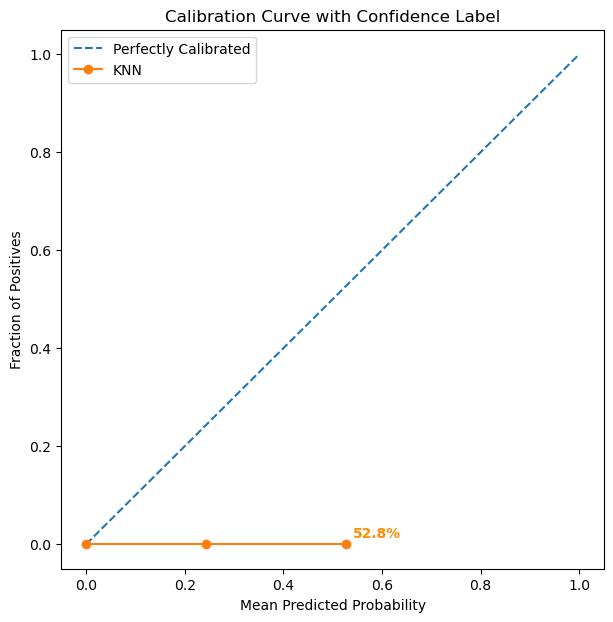

In [51]:
plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfectly Calibrated')
plt.plot(prob_pred, prob_true, marker='o', label='KNN')

# Annotate the last point
plt.annotate(f'{prob_pred[-1]:.1%}', 
             xy=(prob_pred[-1], prob_true[-1]), 
             xytext=(5, 5), textcoords='offset points',
             fontweight='bold', color='darkorange')

plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Positives')
plt.title('Calibration Curve with Confidence Label')
plt.legend()
plt.show()


# The model is unable to identify high adherence from low adherence
# While the model is assigning probabilities, they are based on noisy features that have zero predictive ability
# The model is consistently confident, but in the complete wrong direction
# Ideally the classifier line should trend upwards signaling accuracy
# At its highest confidence level of roughly 52.8%, the model exhibited a 100% error rate